# Simulation with solute transport on Maize root

Read RSML file and run a simulation of the sap flux from a maize de-topped root plunged in a hydroponic solution at a hydrostatic pressure of 0.4 Mpa when its  base is at the atmospheric pressure.

In [1]:
import numpy as np

from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.plantgl.algo.view import view # 2D view

from openalea import hydroroot
from openalea.hydroroot import(
    main,
    hydro_io,
    radius,
    display,
)

## RSML to MTG
1. Read the rsml file and convert it to a MTG g of segments of 0.1 mm

In [2]:
g = hydroroot.hydro_io.read_rsml('data/maize.rsml', segment_length=1.0e-4)

2. Set the root radii
   The radius setting follows the Arabidopsis model describeded in Boursiac et al. 2022. The root radius is set according to the radius of the primary root $r_{ref}$ and the order of the lateral as follows: $r_{lat} = \beta^{order} r_{ref}$. $\beta$ is the radius decreasing facteur between root orders.

In [3]:
# primary root radius 0.5 mm, beta = 0.36
g = hydroroot.radius.ordered_radius(g,
                                    ref_radius=0.5e-3,
                                    order_decrease_factor=0.4)

# Compute the position of each segment relative to the axis bearing it
g = hydroroot.radius.compute_relative_position(g)

## 2.	Setting axial and radial parameters

In [4]:
# radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
kx=np.array([0.0, 0.43]) # distance to tip (m)
ky=np.array([174.7,174.7]) # kr (10-9 m.s-1.MPa-1)
k_radial_data=(kx,ky)

# axial conductance profile: distance to tip (m) vs Kx (10-9 m4.s-1.MPa-1)
Kx=np.array([0, 0.06, 0.13, 0.18, 0.23, 0.29, 0.43]) # distance to tip (m)
Ky=np.array([2.3E-04, 2.3E-04, 2.23E-02, 2.20E-02, 2.17E-02, 2.58E-02, 1.95E-01]) # Kx (10-9 m4.s-1.MPa-1)
K_axial_data=(Kx,Ky)


## Hydraulic Flux calculation

for a detopped root in a hydroponic medium at 0.1 MPa, its base at 0.1 MPa, first without solute transport parameters.

In [5]:
g, Keq, jv = hydroroot.main.hydroroot_flow(g,
                            psi_e = 0.1,
                            psi_base = 0.1,
                            axial_conductivity_data = K_axial_data, 
                            radial_conductivity_data = k_radial_data)

Print resuls

In [6]:
print(f'sap flux (microL/s): {jv:.2e}')

sap flux (microL/s): 0.00e+00


As expected without any hydraulic potential difference there is no outgoing sap flux.

## Add solute transport parameters
We now add an active puping rate $J_S = 1.7 \ 10^{-7} \ mol.m^{-2}.s^{-1}$, a permeability $P_S = 0.6 \ 10^{-9} \ m.s^{-1}$ and a solute concentration in the xylem vessels 
$Cse = 13.69 \ 10^{-9} \ mol.{\mu L}^{-1}$.
Despite the absence of hydrostatic pression difference we observe a flux because of the osmotic potential difference between the xylem vessels and the external medium.

sap flux (microL/s): 2.84e-02


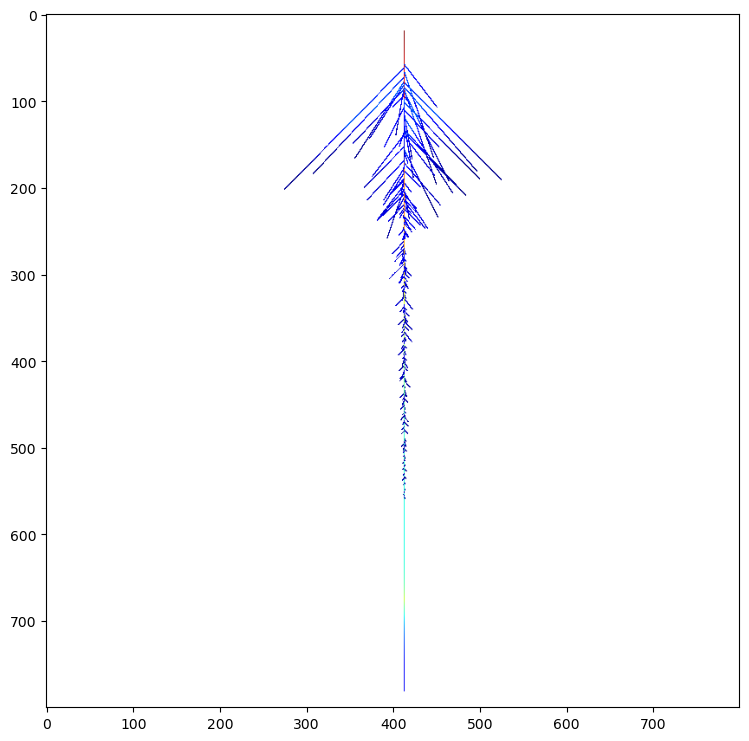

/home/bauget/Documents/Dev/hydroroot/src/openalea/hydroroot/display.py:290: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


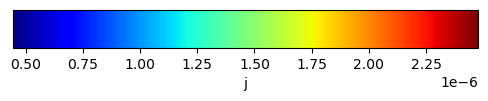

In [7]:
g, jv = hydroroot.main.hydroroot_solute_flow(g,
                            psi_e = 0.1,
                            psi_base = 0.1,
                            axial_conductivity_data = K_axial_data,
                            radial_conductivity_data = k_radial_data,
                            J_s = 1.7e-7, Ps = 0.6e-9, Cse = 13.69e-9)
print(f'sap flux (microL/s): {jv:.2e}')
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')

## Increasing the active pumping rate

sap flux (microL/s): 3.07e-02


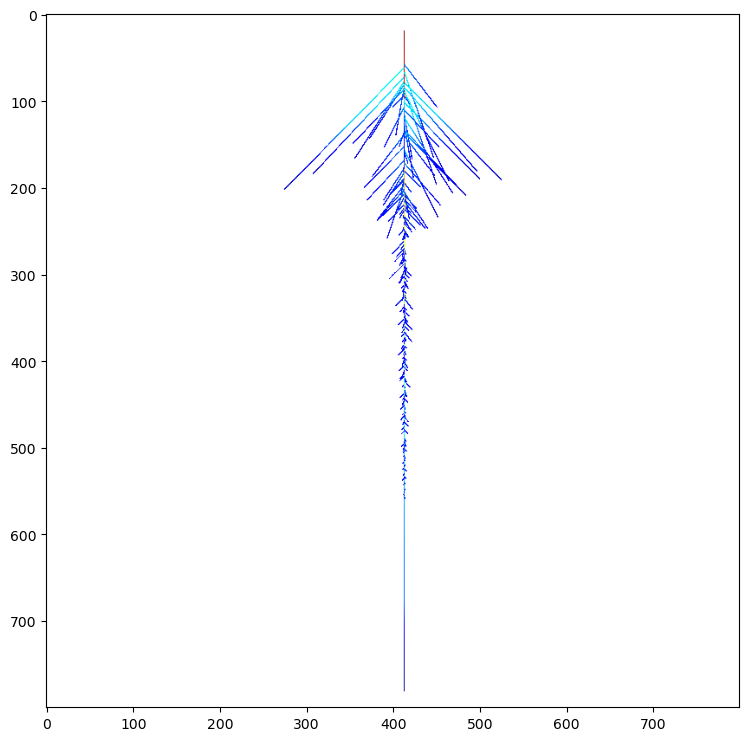

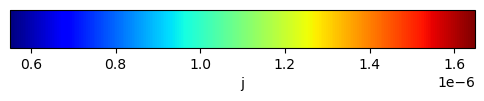

In [8]:
g, jv = hydroroot.main.hydroroot_solute_flow(g, psi_e = 0.1, psi_base = 0.1,
                            axial_conductivity_data = K_axial_data,
                            radial_conductivity_data = k_radial_data, J_s = 1.7e-6, Ps = 0.6e-9, Cse = 13.69e-9)
print(f'sap flux (microL/s): {jv:.2e}')
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')